# Pillar 2 — Warehouse explorer
Live queries on `outputs/presight_warehouse.duckdb` (build it with `run_sql.py`).

In [1]:
import os, sys
ROOT = os.getcwd()
while not os.path.isdir(os.path.join(ROOT, "datasets")):
    ROOT = os.path.dirname(ROOT)
os.chdir(ROOT)
R = "outputs/results/mohammed_faisal"
import pandas as pd
pd.set_option("display.width", 200, "display.max_columns", 30)
print("repo root:", ROOT)
import duckdb
con = duckdb.connect("outputs/presight_warehouse.duckdb", read_only=True)
q = lambda s: con.sql(s).df()

repo root: C:\Users\mohammed.faisal\OneDrive - Presight AI\Desktop\stackup-engineering-academy_assessment


In [2]:
q("SELECT table_name, estimated_size AS rows FROM duckdb_tables() WHERE table_name LIKE 'dim_%' OR table_name LIKE 'fact_%' OR table_name LIKE 'bridge_%' ORDER BY 1")

,table_name,rows
0,bridge_employee_project,42595
1,dim_date,11323
2,dim_employee,2231
3,dim_project,500
4,dim_vendor,25
5,fact_transactions,50000


## SCD2 checks

In [3]:
q("SELECT COUNT(*) AS versions, COUNT(DISTINCT employee_id) AS employees, SUM(is_current::INT) AS current_rows FROM dim_employee")

,versions,employees,current_rows
0,2231,1000,1000.0


In [4]:
q("SELECT * FROM dim_employee WHERE employee_id = (SELECT employee_id FROM dim_employee GROUP BY 1 ORDER BY COUNT(*) DESC, 1 LIMIT 1) ORDER BY valid_from")

,employee_key,employee_id,full_name,email,department,role,level,salary,hire_date,manager_id,region,status,years_experience,valid_from,valid_to,is_current,change_type,change_reason
0,59,EMP0026,Ahmed Farooq,ahmed.farooq@presight.ai,Sustainability,Data Analyst,Junior,10677.0,2021-02-24,EMP0049,Dubai,Active,4,2021-02-24,2021-11-02,False,Hire,Initial appointment
1,60,EMP0026,Ahmed Farooq,ahmed.farooq@presight.ai,Sustainability,Data Analyst,Junior,11614.0,2021-02-24,EMP0049,Dubai,Active,4,2021-11-02,2022-02-08,False,Annual Raise,Annual performance increase
2,61,EMP0026,Ahmed Farooq,ahmed.farooq@presight.ai,Sustainability,Data Analyst,Junior,13086.0,2021-02-24,EMP0049,Dubai,Active,4,2022-02-08,2022-05-24,False,Annual Raise,Market correction adjustment
3,62,EMP0026,Ahmed Farooq,ahmed.farooq@presight.ai,Sustainability,Data Analyst,Junior,13812.0,2021-02-24,EMP0049,Dubai,Active,4,2022-05-24,2025-06-30,False,Annual Raise,Market correction adjustment
4,63,EMP0026,Ahmed Farooq,ahmed.farooq@presight.ai,Sustainability,Data Analyst,Mid,18100.0,2021-02-24,EMP0049,Dubai,Active,4,2025-06-30,9999-12-31,True,Promotion,Annual performance increase


## Q1 department budget performance

In [5]:
q("SELECT department, SUM(budget) b, SUM(actual_cost) a, ROUND(100.0*SUM(actual_cost)/SUM(budget),2) pct FROM dim_project GROUP BY 1 ORDER BY pct DESC")

,department,b,a,pct
0,Legal,26490000.0,23959404.0,90.45
1,Procurement,22460000.0,20048714.0,89.26
2,Finance,31070000.0,27581728.0,88.77
3,HR,25410000.0,22481570.0,88.48
4,Marketing,20520000.0,17660106.0,86.06
5,Digital,26070000.0,21973878.0,84.29
6,Data Science,16530000.0,13928128.0,84.26
7,Sales,22180000.0,18532534.0,83.56
8,Engineering,18270000.0,15213837.0,83.27
9,IT,19040000.0,15795593.0,82.96


## Q3 vendor share (no vendor exceeds 5%)

In [6]:
q("SELECT v.vendor_name, ROUND(100.0*SUM(f.amount)/SUM(SUM(f.amount)) OVER (),2) pct FROM fact_transactions f JOIN dim_vendor v USING (vendor_key) GROUP BY 1 ORDER BY 2 DESC LIMIT 8")

,vendor_name,pct
0,Integra Tech,4.36
1,QuantumByte,4.36
2,PayGate MENA,4.30
3,CX Dynamics,4.23
4,TechBuild LLC,4.20
5,AnalyticsPro,4.14
6,Sage Advisory,4.10
7,PowerScale,4.07


## Q5 monthly spend by category (Software)

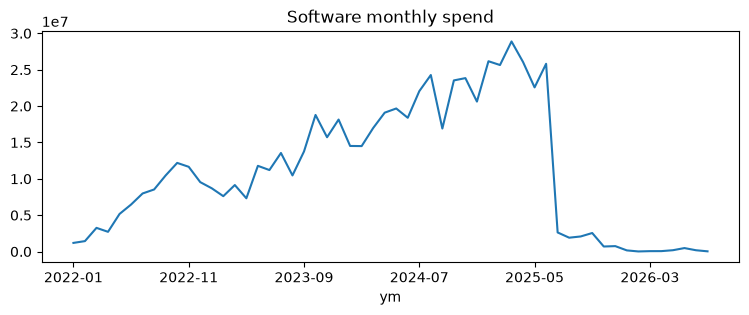

In [7]:
df = q("""WITH m AS (SELECT d.year_month ym, f.category, SUM(f.amount) s FROM fact_transactions f JOIN dim_date d USING (date_key) GROUP BY 1,2)
SELECT ym, s, SUM(s) OVER (ORDER BY ym) running FROM m WHERE category = 'Software' ORDER BY ym""")
df.set_index("ym")["s"].plot(figsize=(9,3), title="Software monthly spend");

## Q6 largest salary increases

In [8]:
q("SELECT n.employee_id, n.full_name, n.valid_from change_date, p.salary AS previous_salary, n.salary AS new_salary, n.salary-p.salary AS increase FROM dim_employee p JOIN dim_employee n ON n.employee_id=p.employee_id AND n.valid_from=p.valid_to WHERE n.salary>p.salary ORDER BY increase DESC LIMIT 10")

,employee_id,full_name,change_date,previous_salary,new_salary,increase
0,EMP0059,Bilal Al Rumaithi,2009-02-13,33852.0,59572.0,25720.0
1,EMP0211,Mira Al Khaja,2014-05-28,45854.0,69078.0,23224.0
2,EMP0263,Wei Bhatt,2023-01-19,39557.0,62533.0,22976.0
3,EMP0599,Sami Al Mansoori,2018-07-27,42233.0,64777.0,22544.0
4,EMP0179,Khalid Al Naqbi,2009-11-01,40082.0,62270.0,22188.0
5,EMP0228,Nadia Al Suwaidi,2016-05-06,28836.0,49492.0,20656.0
6,EMP0936,Ahmed Mahmoud,2023-04-25,28742.0,48448.0,19706.0
7,EMP0890,Marcus Smith,2022-05-01,29591.0,49121.0,19530.0
8,EMP0921,Karthik Murthy,2023-04-12,28668.0,48034.0,19366.0
9,EMP0193,Dana Al Marri,2022-04-01,48120.0,67168.0,19048.0
